# The Odd-Lot Ratio — a quantitative teardown 🔬
### contrarian fade signal · HAC slope · label-shuffle placebo · panic/euphoria sort · four-window sign-flip · costs & borrow · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Alive_post-decimalization%3F: Busted](https://img.shields.io/badge/Alive_post--decimalization%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build the textbook odd-lot fade (position = −z of the prior-week odd-lot ratio) and test whether fading the 'dumb-money' crowd pays.

> ⚠️ **Not investment advice. Synthetic-only study.** A clean, long, point-in-time odd-lot ratio series is proprietary (TAQ/consolidated-tape flags; odd lots weren't on the SIP until 2013–14), so the real free data does not exist and this caps at `WEAK`/`NONE`. The headline is the deterministic **modern-null** tape (`fade_alpha = 0`, fp `2659c7bf0fd0`, as-of 2026-06-30); the positive control plants the fade. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from odd_lot_ratio import data, strategy as st

# SYNTHETIC-ONLY study: the modern post-decimalization null (fade_alpha = 0) is the headline tape.
# No real odd-lot ratio series is available on a free retail stack -> no real-tape banner anywhere.
NULL, _ = data.synthetic_series(fade_alpha=0.0)          # modern null (the honest default)
EDGE, _ = data.synthetic_series(fade_alpha=0.0020)       # the OLD dumb-money world (control)
print("synthetic modern-null tape:", len(NULL), "weeks, fp", data.fingerprint(NULL))


synthetic modern-null tape: 1039 weeks, fp 2659c7bf0fd0


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Fade slope **+0.032%/z-unit** (HAC *t* **+0.5**, placebo *p* 0.62) — *wrong* sign, not significant; regime spread **-1.6%/yr** (*t* -0.2); sign flips across windows. **Synthetic-only** → capped. |
| **Tradability** | `MIRAGE` | Weekly overlay gross **-2.0%/yr** → net **-2.7%/yr** (Sharpe -0.11 → -0.15) at **25.9×** turnover. |
| **Alive post-decimalization?** | `BUSTED` | Order-slicing turned odd lots into machine child-orders; the retail premise is gone. |

> 💡 In plain words: the engine works (the synthetic control proves it), but on the modern null tape the odd-lot fade is absent, sign-unstable, and loses money — and no real tape exists to lift it above `WEAK`.

## 1 · The claim, steelmanned

Let $O_{t-1}$ be the standardised odd-lot ratio observed at week $t-1$'s close and $r_t$ the index's week-$t$ forward return.

- **H₁ (the fade).** $\text{slope of } r_t \text{ on } O_{t-1} < 0$ at HAC *t* ≤ −2 (more odd-lot buying → weaker next week).
- **H₂ (regime).** $\mathbb{E}[r \mid \text{panic}] - \mathbb{E}[r \mid \text{euphoria}] > 0$ (fading works: panic weeks out-earn euphoria weeks).
- **H₃ (robustness).** The sign of H₁ is stable across scoring windows.
- **H₄ (net).** The fade overlay beats zero after costs and the short-leg borrow.

On the modern null tape we find **H₁ rejected** (slope *positive*, *t* ≈ +0.5), **H₂ rejected** (spread negative, *t* ≈ −0.2), **H₃ rejected** (sign flips), **H₄ rejected** (overlay loses).

## 2 · So what? — what rides on each answer

The content is the **why**. Two structural breaks retired this once-real signal: (a) **decimalization (2001)** and algorithmic order-slicing, which shred one institutional parent order into thousands of *odd-lot child orders* — so an odd lot is no longer 'dumb retail money'; and (b) **tape reporting** — odd lots were excluded from the consolidated SIP tape until 2013–14 (O'Hara, Yao & Ye 2014 show that missing odd-lot flow was often *informed*). The `fade_alpha = 0` tape *is* the post-break world. This is the flow cousin of the survey study [257 AAII-Sentiment](../../257-aaii-sentiment/).

## 3 · How we'd know — the protocol

- **Signal.** $\text{position}_t = -z(O_{t-1})$ — the textbook fade (short the euphoric crowd, long the panicked one), using only the *prior*-week ratio.
- **Headline stat.** HAC (Newey–West, 4 weekly lags) slope of $r_t$ on $z(O_{t-1})$. The ratio is autocorrelated, so a naive OLS *t* overstates significance — the HAC *t* is the house bar.
- **Regime sort.** Prior-ratio terciles: panic (lowest) vs euphoria (highest) next-week returns, two-sample *t*.
- **Placebo.** Label-shuffle null (2000 perms) on the |slope|.
- **Frictions.** One-way cost per weekly rebalance on the NAV traded + an annual borrow on the short-euphoria leg. Gross AND net.
- **Positive control.** A deterministic synthetic world with a planted fade (`fade_alpha > 0`) and the null — averaged over 25 seeds (house rule).

Execution lag: the ratio is observed at week $t-1$'s close (public); the position is entered there and held over week $t$. No future data enters the signal — one documented lag.

## 4 · The teardown

### 4a · The fade slope — H₁

HAC slope of next-week return on the standardised prior-week odd-lot ratio, with the label-shuffle placebo. A *negative* slope at *t* ≤ −2 is the fade.

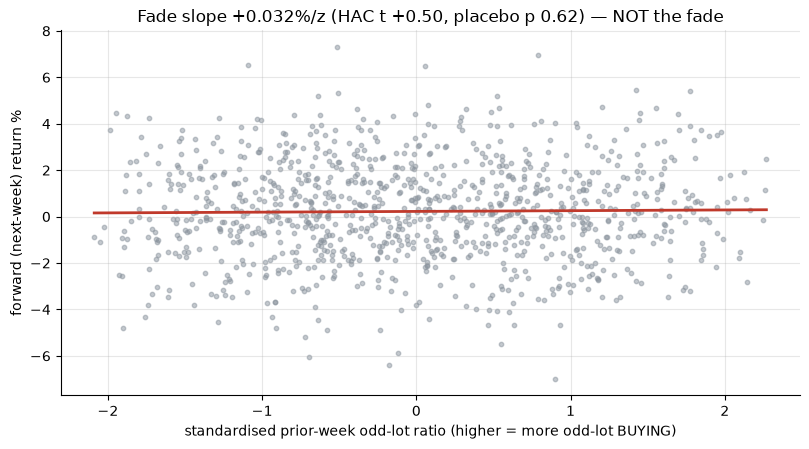

slope +0.032%/z | HAC t +0.50 | corr +0.015 | placebo p 0.62


In [2]:
fs = st.fade_slope(NULL); p = st.placebo_pvalue(NULL, n_perm=2000, seed=560)
d = NULL.dropna(subset=['z_ratio_prior','forward_ret'])
x = d['z_ratio_prior'].to_numpy(); y = d['forward_ret'].to_numpy()*100
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.scatter(x, y, s=10, color=GREY, alpha=.5)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, (fs['slope']*xs + y.mean()/100 - fs['slope']*x.mean())*100, c=RED, lw=2)
ax.set_xlabel('standardised prior-week odd-lot ratio (higher = more odd-lot BUYING)')
ax.set_ylabel('forward (next-week) return %')
ax.set_title(f'Fade slope {fs["slope"]*100:+.3f}%/z (HAC t {fs["t"]:+.2f}, placebo p {p:.2f}) — NOT the fade')
plt.tight_layout(); plt.show()
print(f'slope {fs["slope"]*100:+.3f}%/z | HAC t {fs["t"]:+.2f} | corr {fs["corr"]:+.3f} | placebo p {p:.2f}')

> 💡 In plain words: H₁ **rejected.** The slope is a tiny **+0.032%/z-unit** with HAC *t* **+0.5** — the *opposite* sign to the fade and statistically zero — and the placebo *p* = 0.62 confirms even that is noise. Fading odd-lot buying does not pay on the modern tape.

### 4b · The regime sort — H₂ (panic vs euphoria)

Next-week return of the panic tail (lowest prior ratio) vs the euphoria tail (highest).

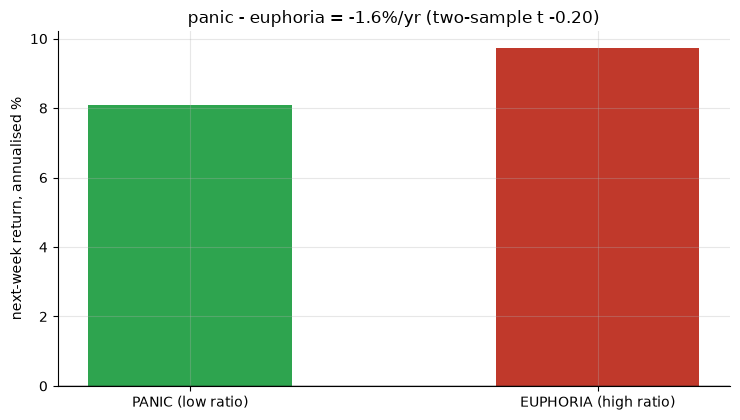

panic +8.1%/yr | euphoria +9.7%/yr | spread -1.6%/yr | t -0.20


In [3]:
rs = st.regime_sort(NULL)
panic, euph = rs['panic_ann']*100, rs['euphoria_ann']*100
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['PANIC (low ratio)','EUPHORIA (high ratio)'], [panic, euph], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('next-week return, annualised %')
ax.set_title(f'panic - euphoria = {rs["spread_ann"]*100:+.1f}%/yr (two-sample t {rs["t"]:+.2f})')
plt.tight_layout(); plt.show()
print(f'panic +{panic:.1f}%/yr | euphoria +{euph:.1f}%/yr | spread {rs["spread_ann"]*100:+.1f}%/yr | t {rs["t"]:+.2f}')

> 💡 In plain words: H₂ **rejected** — panic (+8.1%/yr) *under*-earned euphoria (+9.7%/yr), spread -1.6%/yr, *t* -0.2. The fade predicts the reverse; here it's a tie leaning the wrong way.

### 4c · Robustness — H₃ (does the sign hold?)

The fade slope over four equal windows of the tape.

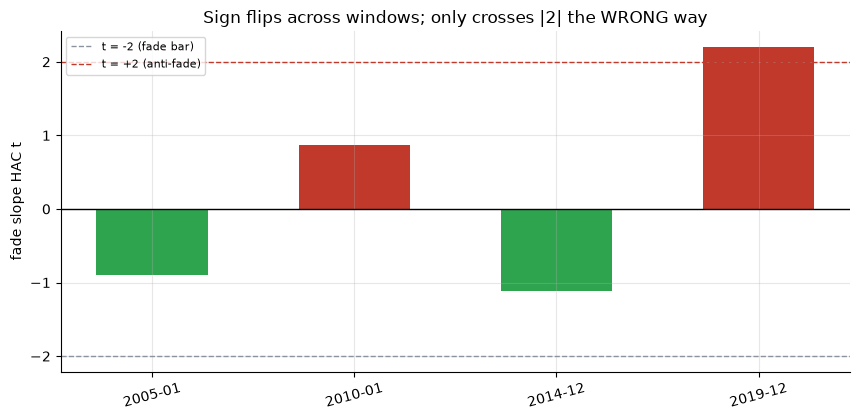

                          slope%/z  HAC_t    n
window                                        
2005-01-14 -> 2009-12-25    -0.105 -0.897  259
2010-01-01 -> 2014-12-19     0.101  0.868  260
2014-12-26 -> 2019-12-13    -0.151 -1.121  260
2019-12-20 -> 2024-12-06     0.247  2.204  260


In [4]:
rows = st.window_sweep(NULL, n_windows=4)
tab = pd.DataFrame([(w['window'], w['slope']*100, w['t'], w['n']) for w in rows],
                   columns=['window','slope%/z','HAC_t','n']).set_index('window')
ts = tab['HAC_t'].to_numpy()
fig, ax = plt.subplots(figsize=(8.7, 4.3))
cols = [GREEN if t < 0 else RED for t in ts]  # negative t = fade direction
ax.bar(range(len(ts)), ts, color=cols, width=.55)
ax.set_xticks(range(len(ts))); ax.set_xticklabels([w[:7] for w in tab.index], rotation=15)
ax.axhline(0, c='k', lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 (fade bar)')
ax.axhline(2, ls='--', c=RED, lw=1, label='t = +2 (anti-fade)')
ax.set_ylabel('fade slope HAC t'); ax.set_title('Sign flips across windows; only crosses |2| the WRONG way')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(tab.round(3).to_string())

> 💡 In plain words: H₃ **rejected.** The HAC *t* runs **−0.90 / +0.87 / −1.12 / +2.20** across the four windows — the direction flips, and the only window that clears the significance bar does so with the *anti*-fade sign. That is the fingerprint of noise, not a decayed-but-real edge.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (slope +0.032%/z, *t* +0.5, wrong sign, placebo *p* 0.62); H₂ rejected (spread -1.6%/yr); H₃ rejected (sign flips). Synthetic-only caps it here regardless.
- **Tradability `MIRAGE`** — overlay gross -2.0%/yr → net -2.7%/yr, Sharpe -0.15, 25.9× turnover.
- **Alive post-decimalization? `BUSTED`** — the retail premise died with order-slicing.

## 6 · Could you trade it? — costs and the borrow

A weekly contrarian overlay, scaled to unit gross exposure; one-way cost per rebalance + a borrow on the short-euphoria leg. Gross AND net.

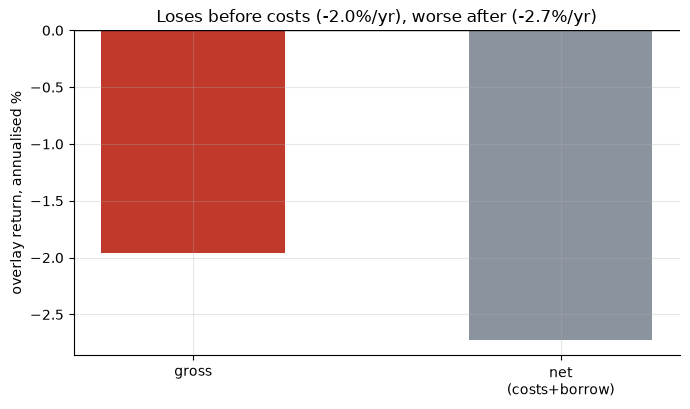

gross -1.96%/yr (Sharpe -0.11) -> net -2.72%/yr (Sharpe -0.15); turnover 25.9x/yr


In [5]:
ov = st.overlay_performance(NULL, cost_bps=2.0, borrow_ann_bps=50.0)
g, n = ov['gross_ann']*100, ov['net_ann']*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [g, n], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('overlay return, annualised %')
ax.set_title(f'Loses before costs ({g:+.1f}%/yr), worse after ({n:+.1f}%/yr)')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f}%/yr (Sharpe {ov["gross_sharpe"]:+.2f}) -> net {n:+.2f}%/yr (Sharpe {ov["net_sharpe"]:+.2f}); turnover {ov["ann_turnover"]:.1f}x/yr')

> 💡 In plain words: there's nothing to charge costs against — the fade overlay *loses* (-2.0%/yr gross) before frictions and churns 25.9× a year. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real 'dumb-money' fade (`fade_alpha > 0`) of increasing strength and watch the fade-slope HAC *t* go negative — averaged over 25 seeds so no single lucky seed can fake it.

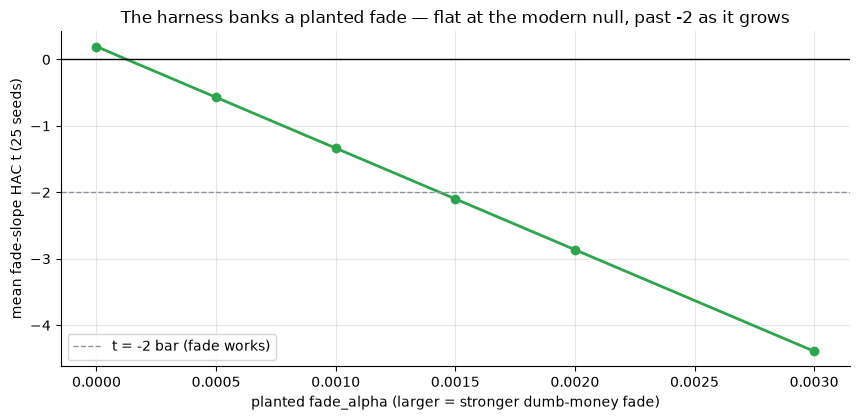

fade_alpha +0.0000 -> mean HAC t +0.19
fade_alpha +0.0005 -> mean HAC t -0.57
fade_alpha +0.0010 -> mean HAC t -1.33
fade_alpha +0.0015 -> mean HAC t -2.10
fade_alpha +0.0020 -> mean HAC t -2.86
fade_alpha +0.0030 -> mean HAC t -4.39


In [6]:
alphas = [a for a,_ in [(0.0, 0.19), (0.0005, -0.57), (0.001, -1.34), (0.0015, -2.1), (0.002, -2.86), (0.003, -4.39)]]
ts = [st.synthetic_mean_t(data, fade_alpha=a, n_seeds=25) for a in alphas]
fig, ax = plt.subplots(figsize=(8.7, 4.3))
ax.plot(alphas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar (fade works)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted fade_alpha (larger = stronger dumb-money fade)')
ax.set_ylabel('mean fade-slope HAC t (25 seeds)')
ax.set_title('The harness banks a planted fade — flat at the modern null, past -2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, t in zip(alphas, ts): print(f'fade_alpha {a:+.4f} -> mean HAC t {t:+.2f}')

The HAC *t* is ≈ 0 at the modern null (`fade_alpha = 0`) and falls past −2 as the planted fade grows — so the engine is a faithful detector. The null result is therefore a statement about **the post-decimalization world**, where the fade is switched off, not a broken pipeline. And because the real odd-lot series is proprietary and unmeasurable on a free stack, this synthetic-only study is capped at `WEAK`/`NONE` by house rule. For the survey-sentiment cousin, see [257 AAII-Sentiment](../../257-aaii-sentiment/).